In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from the CSV file
d = pd.read_csv('retail_store_sales.csv')

# 2. Look at the first 5 rows to see what we have
print("--- Data Preview ---")
d.head(10)

--- Data Preview ---


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [ ]:
# Define our 3 key columns
check_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

# 1. Count how many missing values each row has in those 3 columns
missing_counts = d[check_cols].isnull().sum(axis=1)
# print(missing_counts)

# 2. Keep only the rows where missing values are LESS than 2
# (This means we keep rows with 0 or 1 missing value)
df = d[missing_counts < 2].copy()

print(f"Rows kept after smart cleaning: {len(df)}")

0        0
1        0
2        0
3        0
4        0
        ..
12570    0
12571    0
12572    0
12573    0
12574    0
Length: 12575, dtype: int64
Rows kept after smart cleaning: 11971


In [39]:
# If Total Spent is missing: Calculate it (Quantity * Price)
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

# If Quantity is missing: Calculate it (Total Spent / Price)
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

# If Price is missing: Calculate it (Total Spent / Quantity)
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])

# Final check: fill 'Discount Applied' with False if empty
df['Discount Applied'] = df['Discount Applied'].fillna(False)

# print("Missing values have been calculated and filled!") 
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,20.0,10.0,200.0,Credit Card,Online,2023-11-30,False
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
10,TXN_8776416,CUST_22,Butchers,Item_3_BUT,8.0,9.0,72.0,Cash,In-store,2024-12-14,True


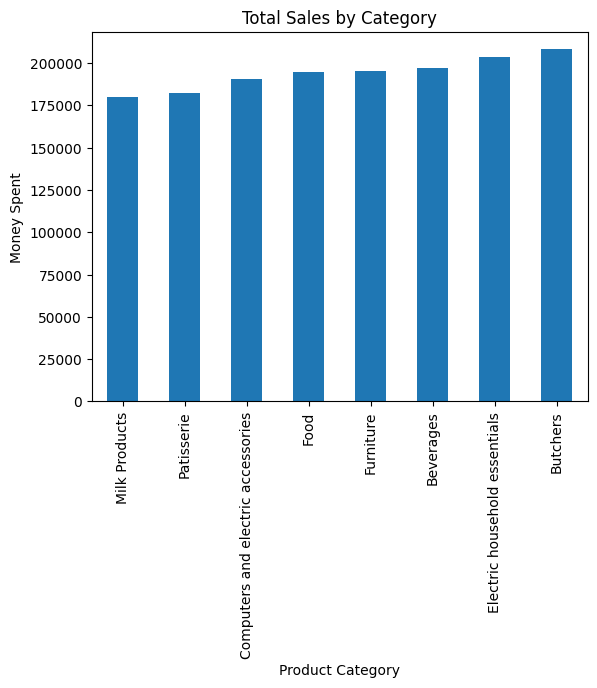

In [49]:
# Group by Category and add up the Total Spent
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values()

# Create a Bar Chart
category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.ylabel('Money Spent')
plt.xlabel('Product Category')
plt.show()

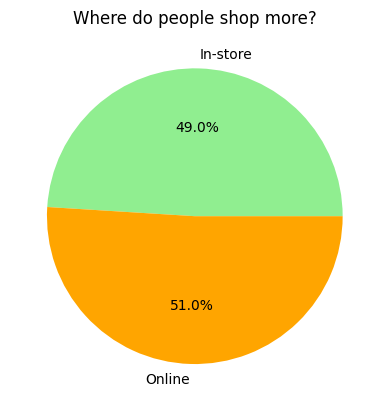

In [47]:
# Group by Location and sum the sales
location_sales = df.groupby('Location')['Total Spent'].sum()

# Create a Pie Chart
location_sales.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'orange'])
plt.title('Where do people shop more?')
plt.show()

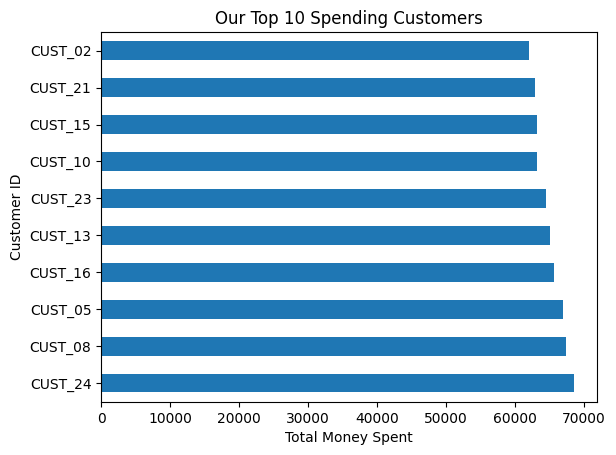

In [42]:
# Find the top 10 customers who spent the most
top_customers = df.groupby('Customer ID')['Total Spent'].sum().nlargest(10)

top_customers.plot(kind='barh')
plt.title('Our Top 10 Spending Customers')
plt.xlabel('Total Money Spent')
plt.show()

On average, customers buy 5.54 items per trip.


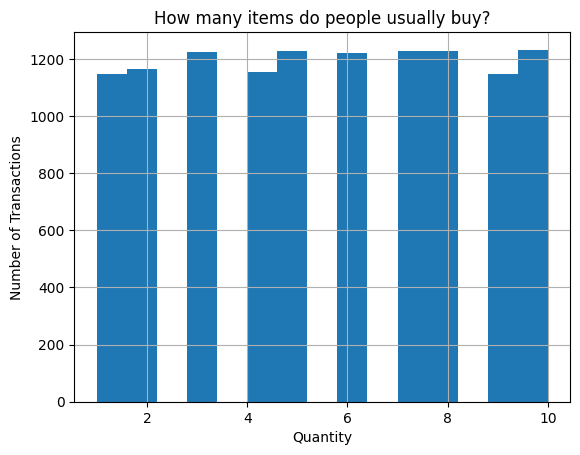

In [46]:
# Calculate the average of the Quantity column
avg_qty = df['Quantity'].mean()
print(f"On average, customers buy {avg_qty:.2f} items per trip.")

# Show a histogram to see how many items people buy
df['Quantity'].hist(bins=15)
plt.title('How many items do people usually buy?')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.show()

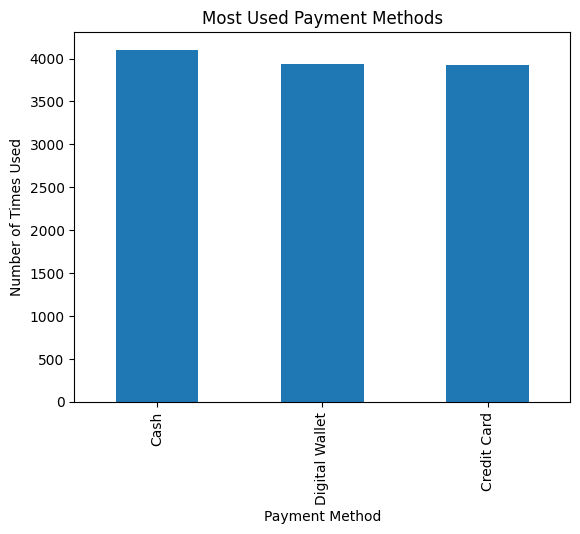

In [ ]:

payment_counts = df['Payment Method'].value_counts() #counting how many time the particular payment method was used

payment_counts.plot(kind='bar')
plt.title('Most Used Payment Methods')
plt.ylabel('Number of Times Used')
plt.show()